## Supernovae 1

Define the needed functions

In [24]:
import numpy as np
from astroML.datasets import generate_mu_z
from matplotlib import pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
import scipy.stats
from sklearn.neighbors import KernelDensity
import astropy.visualization.hist
from scipy.stats import norm
import emcee
import corner
from scipy import stats


Plot the data and try two different kernels for the GPR

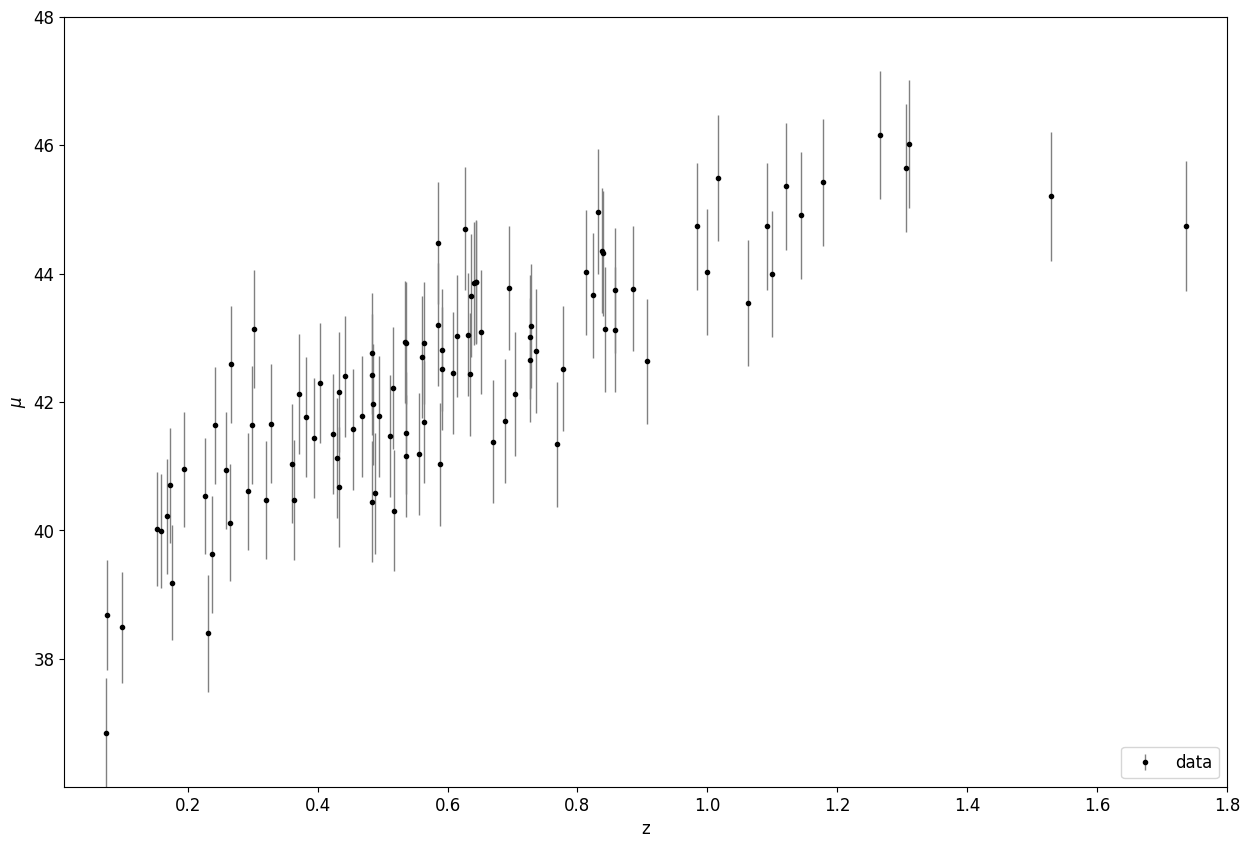

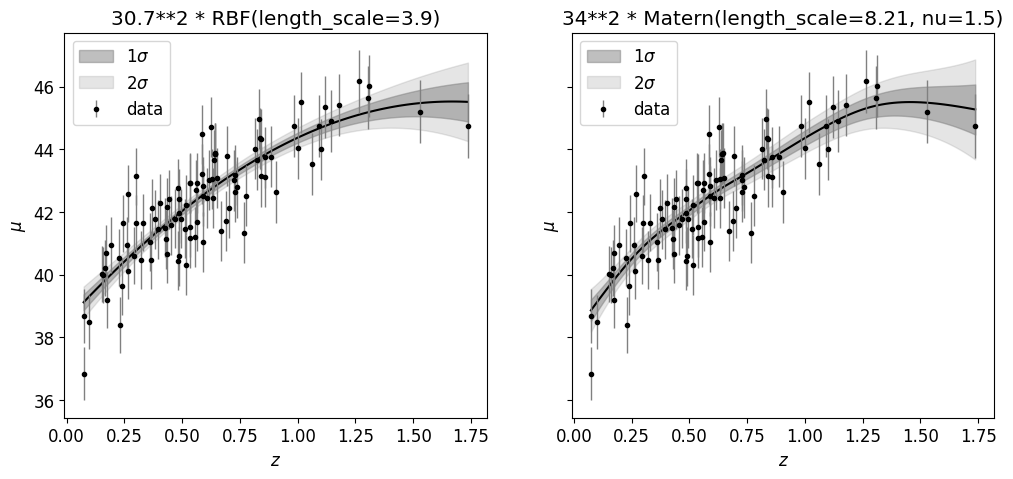

In [25]:
plt.rcParams['figure.figsize'] = [15, 10]
plt.rcParams['font.size'] = 12
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0.01, 1.8)
plt.ylim(36.01, 48)


z_grid = np.linspace(z_sample.min(),z_sample.max(),100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

kernels = [kernels.ConstantKernel() * kernels.RBF(),kernels.ConstantKernel() * kernels.Matern()]
# hyperparameters internally optimized. no need for cross validation

for kernel,ax in zip(kernels,axes):
    gp = GaussianProcessRegressor(kernel=kernel,alpha=dmu**2, random_state=0)
    gp.fit(z_sample[:, None], mu_sample)
    mu_predict, dmu_err = gp.predict(z_grid[:, None],return_std=True)
    
    ax.plot(z_grid, mu_predict, '-', color='black')
    ax.fill_between(z_grid, mu_predict - 1 * dmu_err, mu_predict + 1 * dmu_err,color='gray', alpha=0.5, label='$1\sigma$')
    ax.fill_between(z_grid, mu_predict - 2 * dmu_err, mu_predict + 2 * dmu_err,color='gray', alpha=0.2, label='$2\sigma$')
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
    ax.set_title(gp.kernel_)
    ax.set_ylabel(r'$\mu$')
    ax.set_xlabel(r'$z$')
    ax.legend()


When you have few point, the errors are greater and the fit less reliable. Overall the fit is good in the central part

In the following perform two different density estimation (reject and kde) and sample the distribution with 1000 values

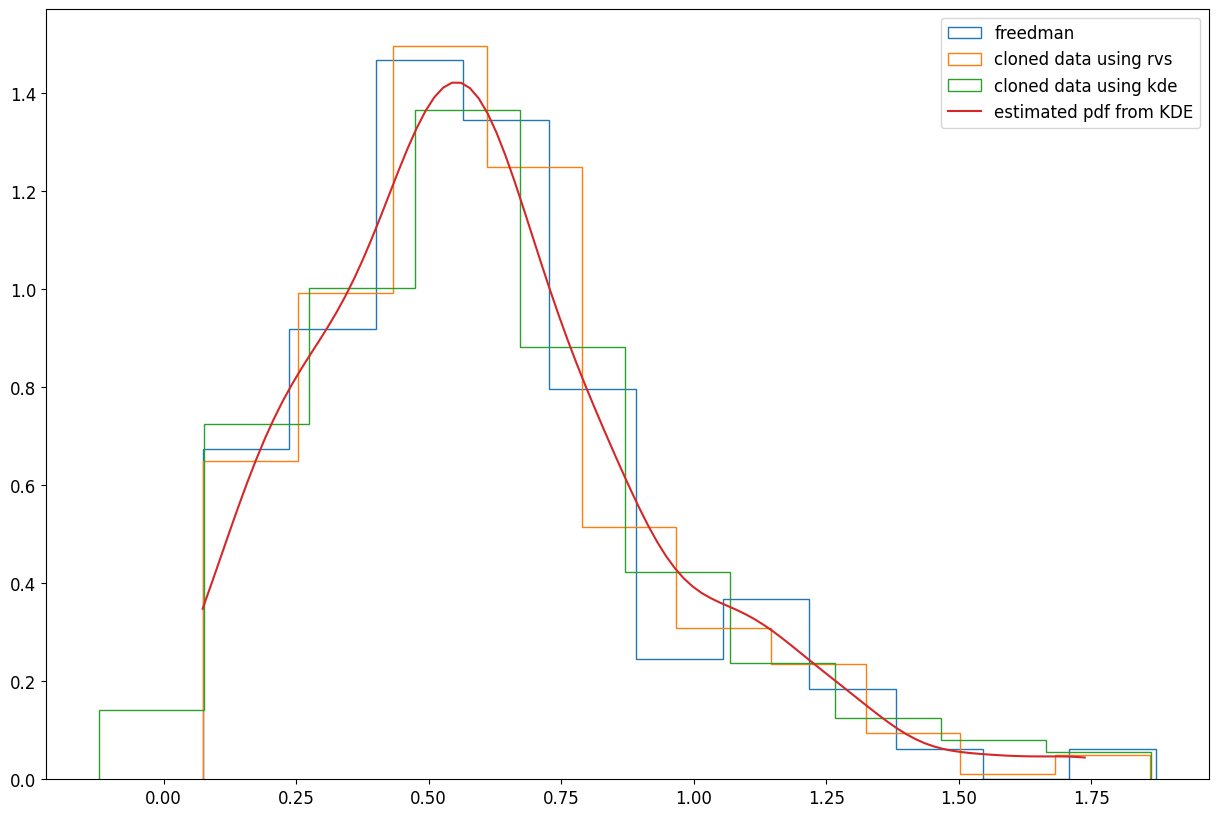

In [26]:
def kde_sklearn(xgrd, data, bandwidth = 0.1, kernel="gaussian"):
    kde_skl = KernelDensity(bandwidth = bandwidth,kernel=kernel)
    fitted_kde = kde_skl.fit(data[:, np.newaxis])
    log_pdf = fitted_kde.score_samples(xgrd[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf), kde_skl

fig, ax = plt.subplots()
#ax.hist(z_sample,bins=10,histtype='step',density=True,label='original z data');
counts, bins, h = astropy.visualization.hist(z_sample, bins="freedman", histtype="step",density=True, label = 'freedman', axes= ax)
# counts, bins = np.histogram(z_sample, bins=50, density=True)
disth = scipy.stats.rv_histogram((counts,bins))
z_sim = np.sort(disth.rvs(size=1000))
ax.hist(z_sim,bins=10,density=True,histtype='step',label='cloned data using rvs');

z_pdf, kde = kde_sklearn(z_grid,z_sample)
z_sim = np.sort(kde.sample(1000),axis=0)
ax.hist(z_sim,bins=10,density=True,histtype='step',label='cloned data using kde');
plt.plot(z_grid,z_pdf,label = 'estimated pdf from KDE')
ax.legend()

Use the simulated z values to predict the mu values. The values fall within the error bands

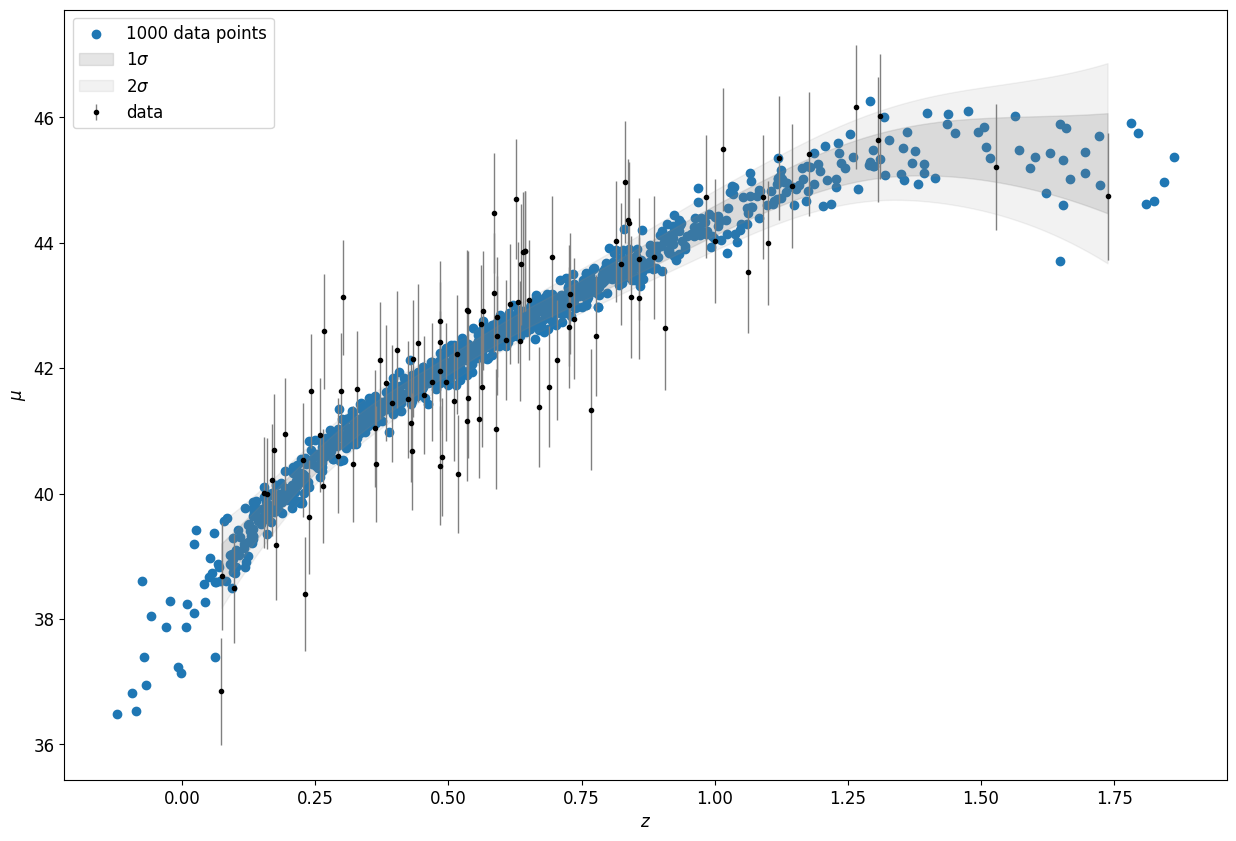

In [27]:
if z_sim.ndim == 1:
    z_sim = z_sim[:,np.newaxis]
# mu_sim = gp.sample_y(z_sim,1)
mu_sim_mean, dmu_err_sim = gp.predict(z_sim,return_std=True)
mu_sim = np.random.normal(loc=mu_sim_mean,scale=dmu_err_sim)
fig, ax = plt.subplots()
ax.scatter(z_sim, mu_sim,label = '1000 data points')
ax.fill_between(z_grid, mu_predict - 1 * dmu_err, mu_predict + 1 * dmu_err,color='gray', alpha=0.2, label='$1\sigma$')
ax.fill_between(z_grid, mu_predict - 2 * dmu_err, mu_predict + 2 * dmu_err,color='gray', alpha=0.1, label='$2\sigma$')
ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
# ax.set_title(gp.kernel_)
ax.set_ylabel(r'$\mu$')
ax.set_xlabel(r'$z$')
ax.legend()


Define the problem using MCMC. Plot the model line using an initial guess

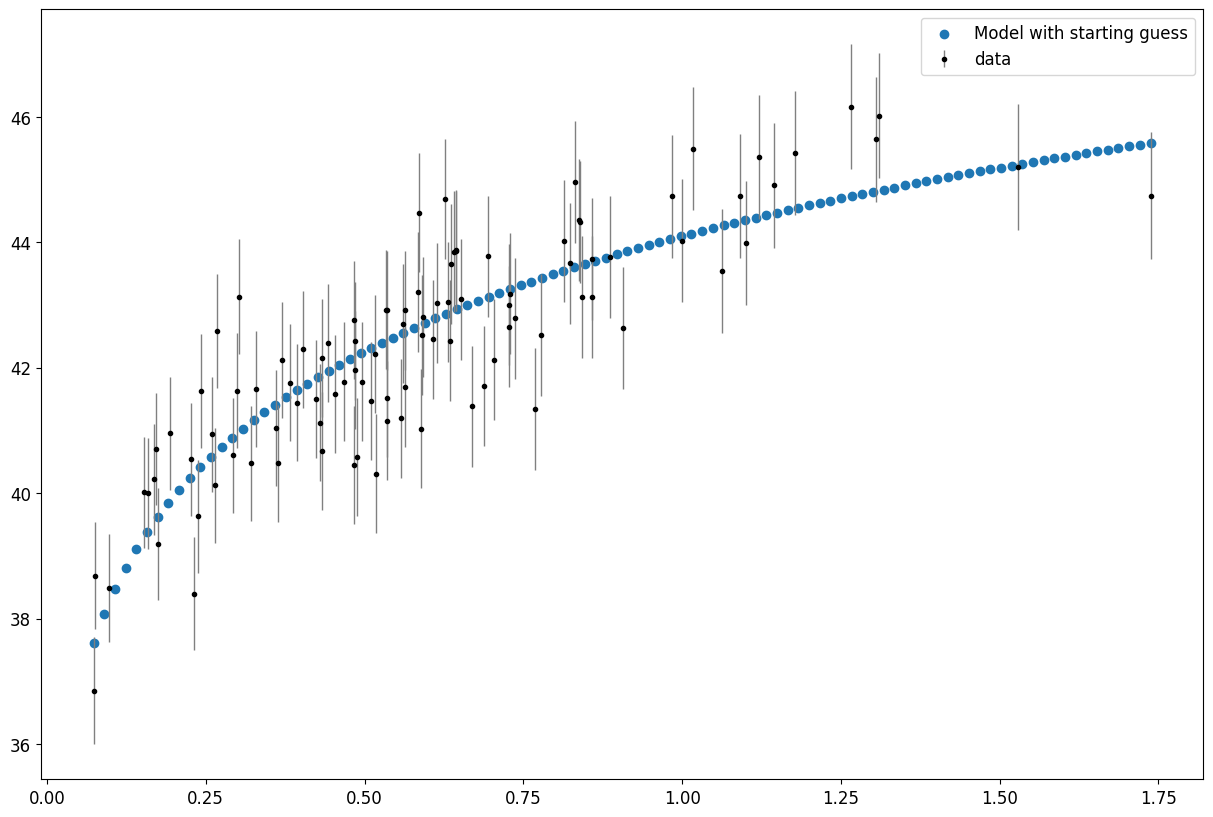

In [28]:
from astropy.cosmology import LambdaCDM
from astroML.datasets import generate_mu_z
def model(theta, z):
    cosmo_tmp = LambdaCDM(H0=theta[0], Om0=theta[1], Ode0=1-theta[1])
    mu_model = cosmo_tmp.distmod(z).value
    return mu_model

def logLikelihood(theta,z,mu,dmu):
    return np.sum(norm(loc = model(theta,z), scale = dmu).logpdf(mu))

def logPrior(theta):
    H0, OmegaM = theta
    if 50 <= H0 <= 150 and 0 <= OmegaM <= 1:
        return -1
    else:
        return -np.inf

def logPosterior(theta,z,mu,dmu):
    
    lp =  logPrior(theta)
    if not np.isfinite(lp):
        return -np.inf
    else:
        return logLikelihood(theta,z,mu,dmu) + lp

fig, ax = plt.subplots()
ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
starting_guesses = np.array([70,0.3])
ax.scatter(z_grid,model(starting_guesses,z_grid),label='Model with starting guess')
ax.legend()



Run the MCMC. Check the walkers, perform the burn and thinning of the trace, compute the statistics, MAP value and 90% credible region

Parameter H0:
  Walker 1: std = 6.4465, mean = 66.6230
  Walker 2: std = 6.0189, mean = 67.5664
  Walker 3: std = 6.1280, mean = 66.9175
  Walker 4: std = 6.3485, mean = 66.8217
  Walker 5: std = 6.2032, mean = 67.0160
  Walker 6: std = 6.4072, mean = 66.5008
  Walker 7: std = 6.4806, mean = 67.1476
  Walker 8: std = 6.3326, mean = 66.5543
  Walker 9: std = 6.2245, mean = 66.3090
  Walker 10: std = 6.0679, mean = 66.5544
  Walker 11: std = 6.2915, mean = 66.9324
  Walker 12: std = 6.5320, mean = 66.5451
Parameter OmegaM:
  Walker 1: std = 0.2655, mean = 0.4766
  Walker 2: std = 0.2486, mean = 0.4523
  Walker 3: std = 0.2573, mean = 0.4821
  Walker 4: std = 0.2612, mean = 0.4888
  Walker 5: std = 0.2516, mean = 0.4602
  Walker 6: std = 0.2584, mean = 0.4983
  Walker 7: std = 0.2596, mean = 0.4675
  Walker 8: std = 0.2586, mean = 0.4792
  Walker 9: std = 0.2671, mean = 0.4983
  Walker 10: std = 0.2566, mean = 0.4856
  Walker 11: std = 0.2614, mean = 0.4721
  Walker 12: std = 0.2648, mean

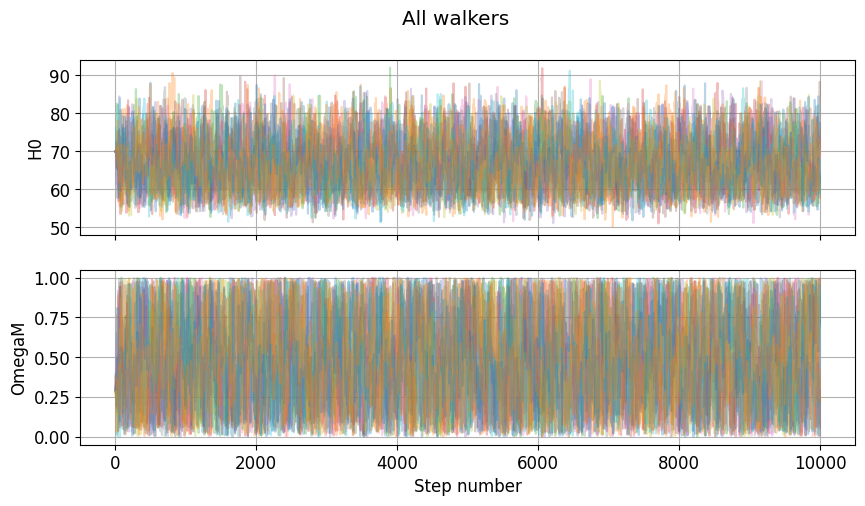

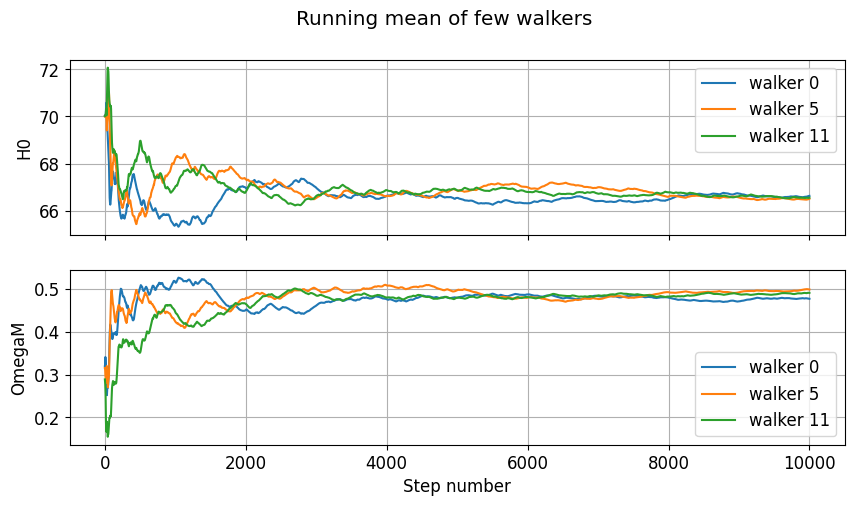

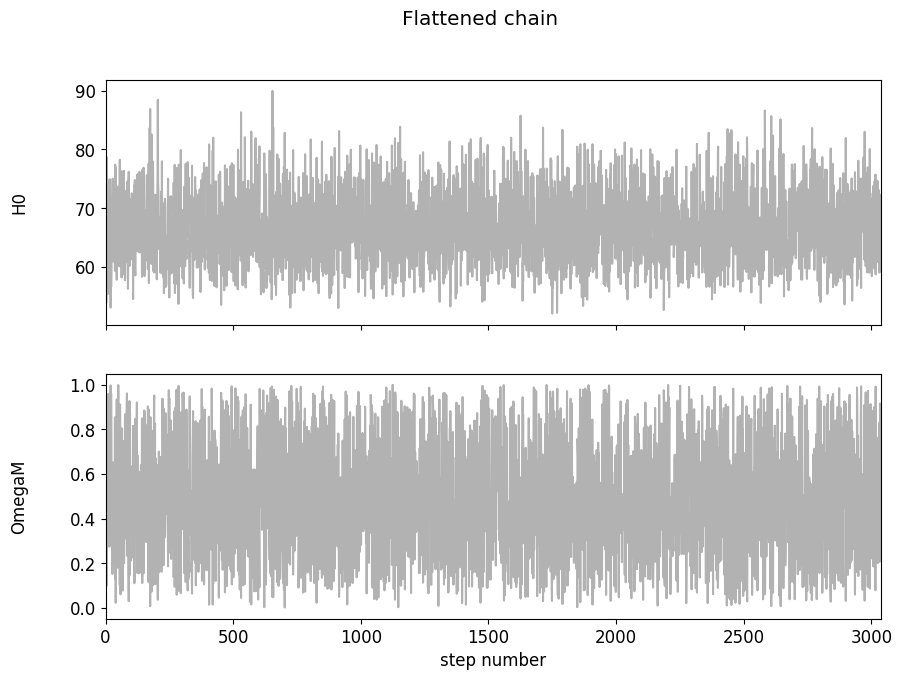

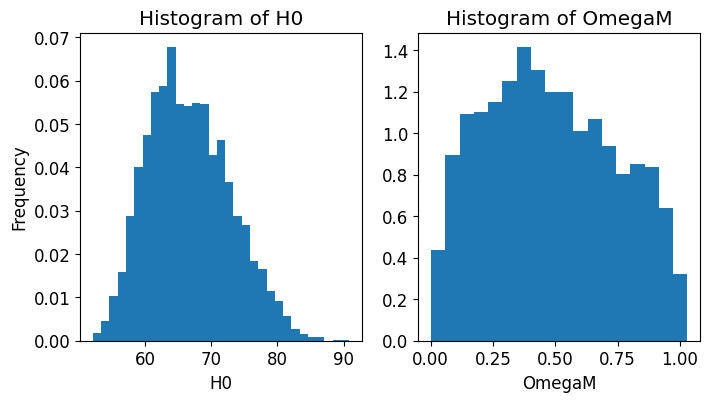

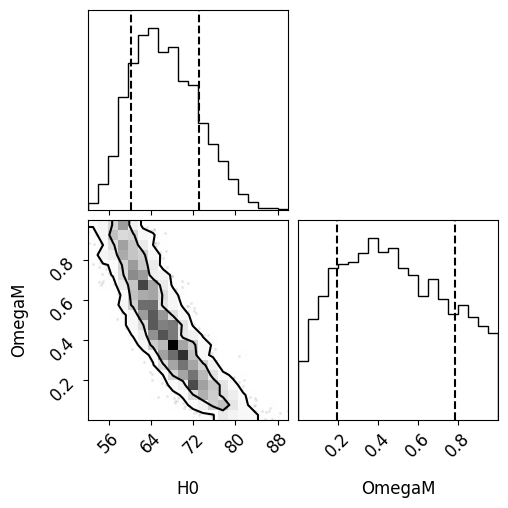

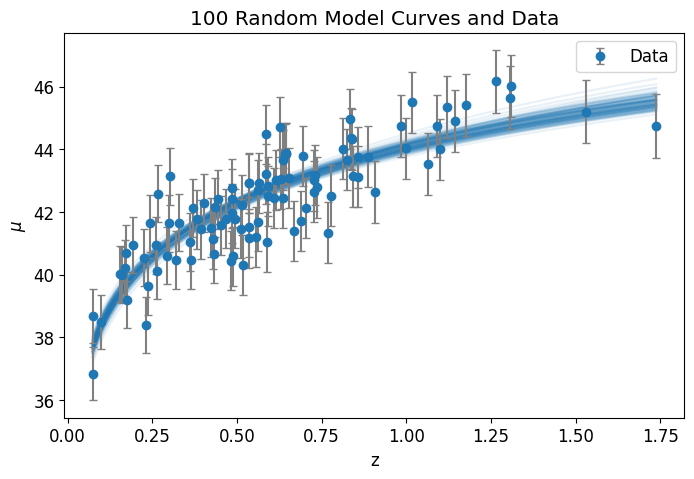

In [29]:
labels = ["H0","OmegaM"]
ndim = 2  # number of parameters in the model
nwalkers = 12  # number of MCMC walkers
nsteps = 10000  # number of MCMC steps to take **for each walker**

np.random.seed(0)
starting_guesses = starting_guesses+1e-2*np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior,args=[z_sample,mu_sample,dmu])
sampler.run_mcmc(starting_guesses, nsteps)
emcee_trace = sampler.get_chain()

# check the walkers if someone gets stuck
fig, axes = plt.subplots(ndim, 1, figsize=(10, 2.5*ndim), sharex=True)

for i in range(ndim):
    ax = axes[i]
    #for w in walker_indices:
    #    ax.plot(emcee_trace[:, w, i], label=f"walker {w}", alpha=0.8)
    ax.plot(emcee_trace[:, :, i], alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.grid(True)
    # ax.legend()
fig.suptitle('All walkers')
axes[-1].set_xlabel("Step number")

for i in range(ndim):
    print(f"Parameter {labels[i]}:")
    for w in range(nwalkers):
        std = np.std(emcee_trace[:, w, i])
        mean = np.mean(emcee_trace[:, w, i])
        print(f"  Walker {w+1}: std = {std:.4f}, mean = {mean:.4f}")
        

# plot running mean
walker_indices = np.linspace(0, nwalkers-1, 3, dtype=int) 
fig, axes = plt.subplots(ndim, 1, figsize=(10, 2.5*ndim), sharex=True)
for i, label in enumerate(labels):
    ax = axes[i]
    for w in walker_indices:
        param_chain = emcee_trace[:, w, i]
        running_mean = np.cumsum(param_chain) / np.arange(1, len(param_chain)+1)
        ax.plot(running_mean, label=f"walker {w}")
    ax.set_ylabel(label)
    ax.grid(True)
    ax.legend(loc="best")
fig.suptitle('Running mean of few walkers')
axes[-1].set_xlabel("Step number")

# define the autocorr time and burn phase
tau = sampler.get_autocorr_time()
print(tau)
thin = int(np.max(tau)+1)
print('Max of autocorrelation time is',thin)
burn = 3*thin

# get the chain
emcee_trace_flat = sampler.get_chain(discard=burn, thin=thin, flat=True)

# plot the flattened chain
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(emcee_trace_flat[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(emcee_trace_flat))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
fig.suptitle('Flattened chain')
axes[-1].set_xlabel("step number");

# plot the histogram
fig, axes = plt.subplots(1, ndim, figsize=(4*ndim, 4))
for i in range(ndim):
    ax = axes[i]
    astropy.visualization.hist(emcee_trace_flat[:, i], bins="freedman",density=True, ax=ax)
    #ax.hist(emcee_trace[:, i], bins=50, color='skyblue', edgecolor='k', alpha=0.7,density=True)
    ax.set_xlabel(labels[i])
    ax.set_title(f"Histogram of {labels[i]}")
axes[0].set_ylabel("Frequency")

fig = corner.corner( emcee_trace_flat, labels=labels,quantiles=(0.16, 0.84), levels=[0.68,0.95]);

# Compute statistics
medians = np.median(emcee_trace_flat, axis=0)
q5 = np.percentile(emcee_trace_flat, 5, axis=0)
q95 = np.percentile(emcee_trace_flat, 95, axis=0)
ul = q95-medians
ll = medians-q5
# Print results
for i, label in enumerate(labels):
    print(f"{label}: median = {medians[i]:.4f}, 5th = {q5[i]:.4f}, 95th = {q95[i]:.4f}. 90% credible region: {medians[i]:.4f}(+{ul[i]:4f}, -{ll[i]:4f})")


log_posteriors = np.array([logPosterior(params, z_sample,mu_sample,dmu) for params in emcee_trace_flat])
map_index = np.argmax(log_posteriors)
map_params = emcee_trace_flat[map_index]
for i, label in enumerate(labels):
    print(f"MAP value for {label}: {map_params[i]:.4f}")

# show the models obtained from the posterior
models = np.array([model(params, z_grid) for params in emcee_trace_flat])
random_indices = np.random.choice(models.shape[0], size=100, replace=False)

plt.figure(figsize=(8, 5))

# Plot 100 random model curves with transparency
for idx in random_indices:
    plt.plot(z_grid, models[idx, :], color='C0', alpha=0.1)

plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='o', 
             ecolor='gray', capsize=3, label='Data')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.title("100 Random Model Curves and Data")
plt.legend()


It seems that the omegaM is poorly constrained having a large 90% confidence interval. Also there is a negative correlation between the parameters.
To be more quantitative

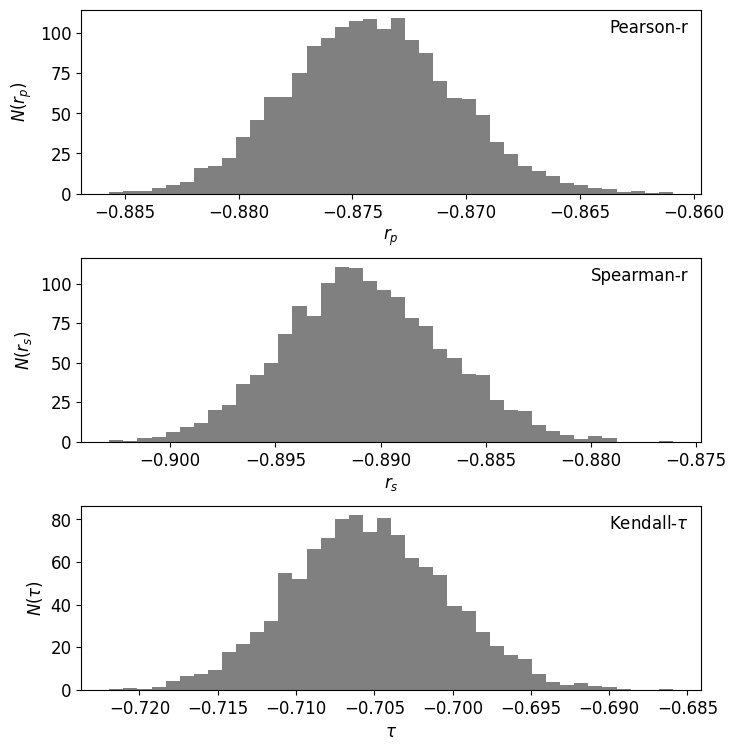

In [18]:
def compute_results(N, Nbootstraps):
    results = np.zeros((3, Nbootstraps))
    for k in range(Nbootstraps):
         ind = np.random.randint(N, size=N)
         x = emcee_trace_flat[ind, 0]
         y = emcee_trace_flat[ind, 1]
         for i, statistic in enumerate([stats.pearsonr,stats.spearmanr,stats.kendalltau]):
             results[i, k] = statistic(x, y)[0]
    return results

results = compute_results(emcee_trace_flat.shape[0], 5000)

#------------------------------------------------------------
# Plot the results in a three-panel plot
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(bottom=0.1, top=0.95, hspace=0.35)
distributions = ['Pearson-r', 'Spearman-r', r'Kendall-$\tau$']
xlabels = ['r_p', 'r_s', r'\tau']
for i in range(3):
    ax = fig.add_subplot(311 + i)
    ax.hist(results[i,:], 40, histtype='stepfilled', fc='gray',density=True)
    ax.text(0.98, 0.95, distributions[i], ha='right', va='top',
            transform=ax.transAxes)
    ax.set_xlabel('$%s$' % xlabels[i])
    ax.set_ylabel('$N(%s)$' % xlabels[i])
plt.show()

Use dynesty to get the estimate of the evidence for checking if the presence of the omegaL is significant or not with these data

1910it [00:23, 79.63it/s, +500 | bound: 1 | nc: 1 | ncall: 19007 | eff(%): 13.022 | loglstar:   -inf < -132.813 <    inf | logz: -135.777 +/-  0.057 | dlogz:  0.001 >  0.509] 


H0: median = 66.3146, 5th = 57.9296, 95th = 77.8973. 90% credible region: 66.3146(+11.582738, -8.384949)
OmegaM: median = 0.4472, 5th = 0.0875, 95th = 0.9204. 90% credible region: 0.4472(+0.473237, -0.359646)


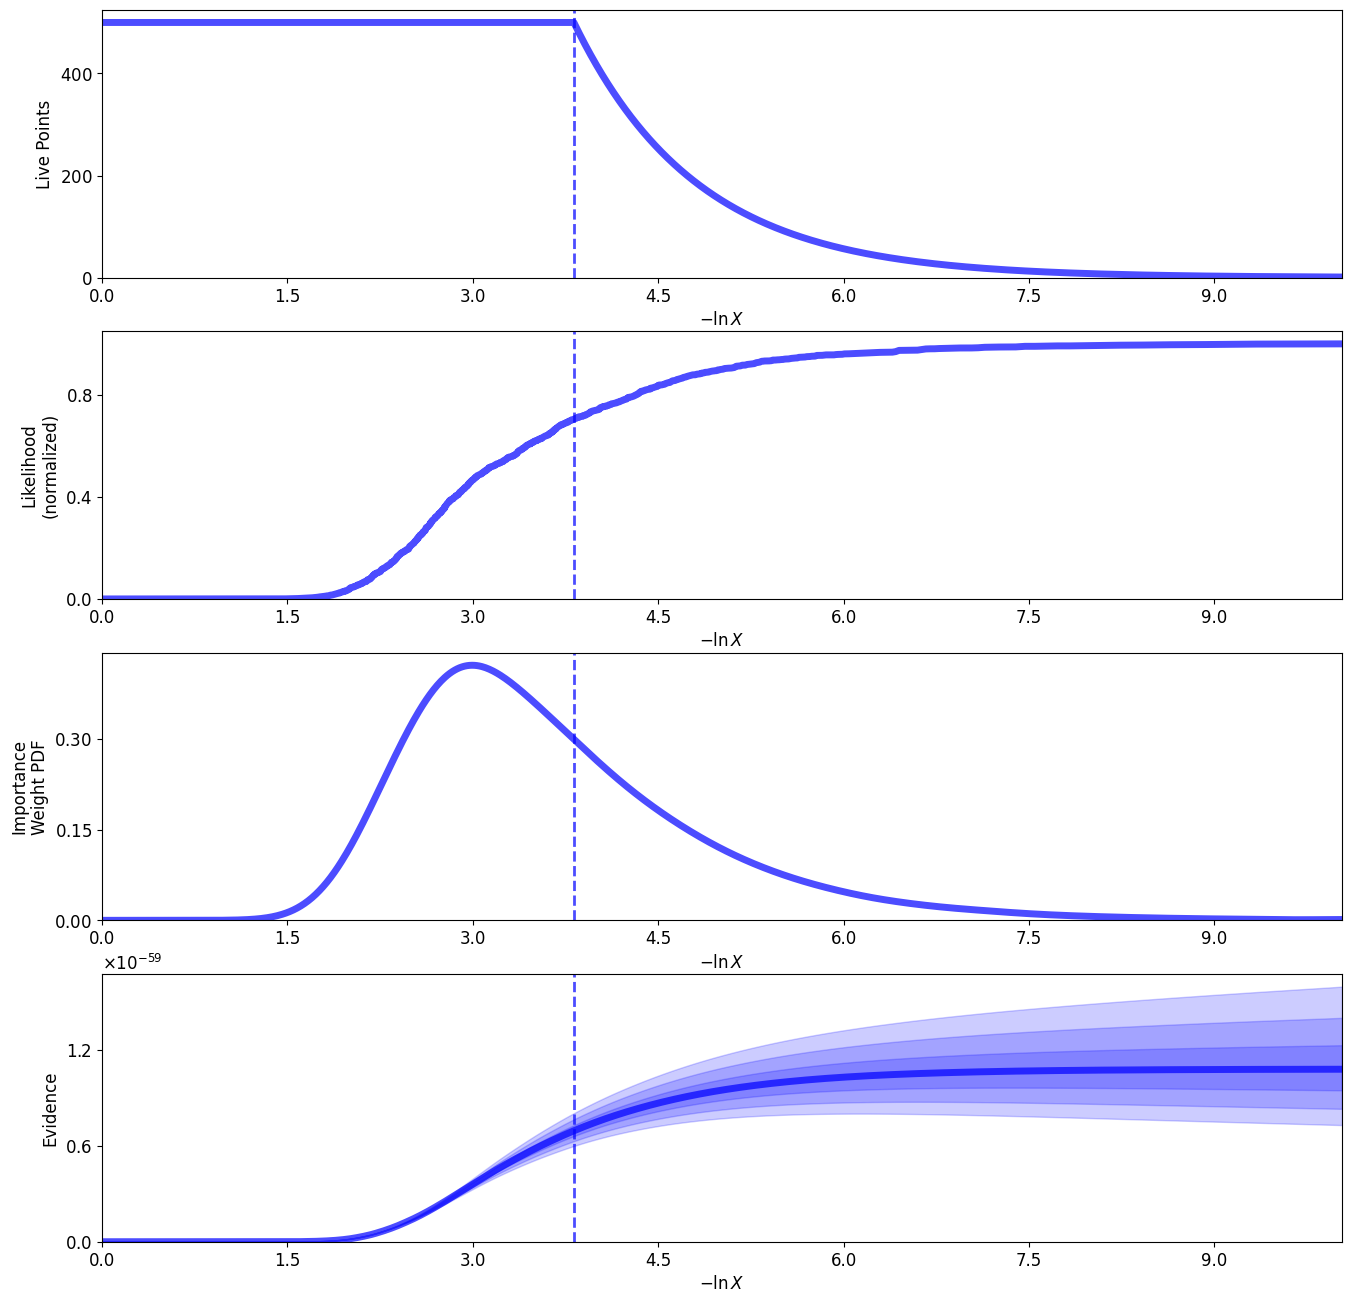

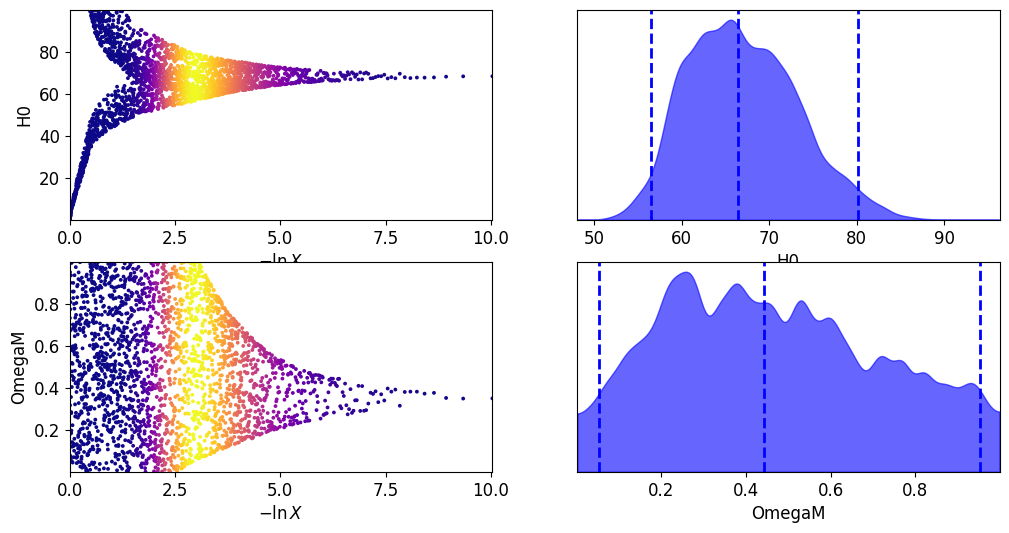

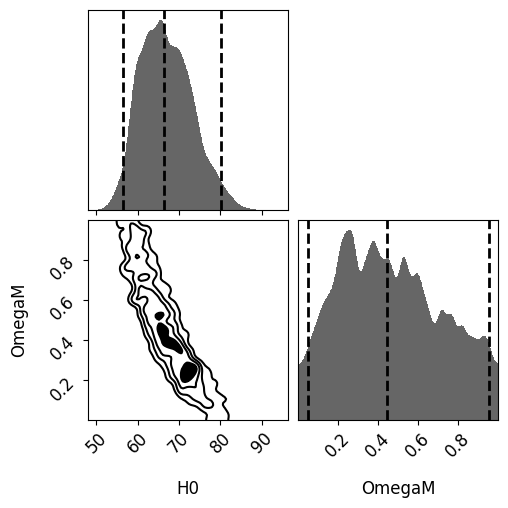

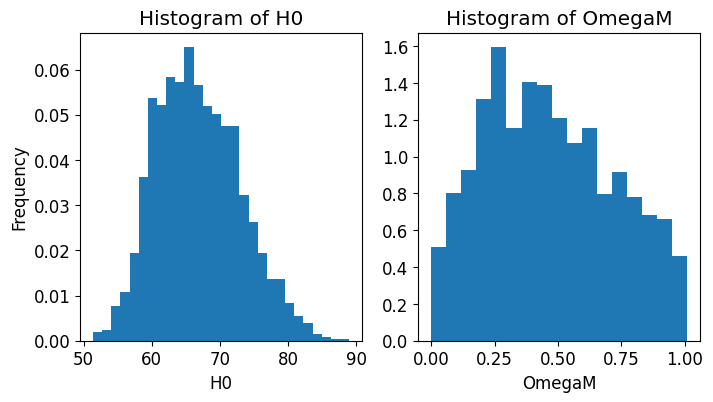

In [19]:
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
def ptform(theta):
    H0, OmegaM = theta
    H0 = 100 * H0           # Uniform in [0, 100]
    OmegaM = 1 * OmegaM         # Uniform in [0, 1]
    return np.array([H0, OmegaM])

def plot(labels,sresults):
    rfig, raxes = dyplot.runplot(sresults)
    tfig, taxes = dyplot.traceplot(sresults,labels=labels)
    cfig, caxes = dyplot.cornerplot(sresults, labels=labels)

    Z = np.exp(sresults.logz[-1])
    # Resample weighted samples.
    weights = sresults.importance_weights()
    samples = sresults.samples
    samples_equal = dyfunc.resample_equal(samples, weights)

    # plot the histogram
    fig, axes = plt.subplots(1, ndim, figsize=(4*ndim, 4))
    for i in range(ndim):
        if ndim == 1:
            ax = axes
        else:
            ax = axes[i]
        astropy.visualization.hist(samples_equal[:, i], bins="freedman",density=True, ax=ax)
        #ax.hist(emcee_trace[:, i], bins=50, color='skyblue', edgecolor='k', alpha=0.7,density=True)
        ax.set_xlabel(labels[i])
        ax.set_title(f"Histogram of {labels[i]}")
    if ndim == 1:
        axes.set_ylabel("Frequency")
    else:
        axes[0].set_ylabel("Frequency")


    # Compute statistics
    medians = np.median(samples_equal, axis=0)
    q5 = np.percentile(samples_equal, 5, axis=0)
    q95 = np.percentile(samples_equal, 95, axis=0)
    ul = q95-medians
    ll = medians-q5
    # Print results
    for i, label in enumerate(labels):
        print(f"{label}: median = {medians[i]:.4f}, 5th = {q5[i]:.4f}, 95th = {q95[i]:.4f}. 90% credible region: {medians[i]:.4f}(+{ul[i]:4f}, -{ll[i]:4f})")
    
    return Z

sampler = dynesty.NestedSampler(logLikelihood, ptform, ndim,logl_args=(z_sample,mu_sample,dmu))
sampler.run_nested()
sresults = sampler.results
Z_OmegaL = plot(labels,sresults)

Use a model where the omegaL is 0 and perform the model comparison

1885it [00:23, 81.84it/s, +500 | bound: 1 | nc: 1 | ncall: 19197 | eff(%): 12.756 | loglstar:   -inf < -133.530 <    inf | logz: -136.397 +/-  0.051 | dlogz:  0.001 >  0.509]


H0: median = 57.7116, 5th = 53.5257, 95th = 61.7440. 90% credible region: 57.7116(+4.032458, -4.185838)
The Bayes factor of OmegaL vs No OmegaL is:  0.6200084345761638


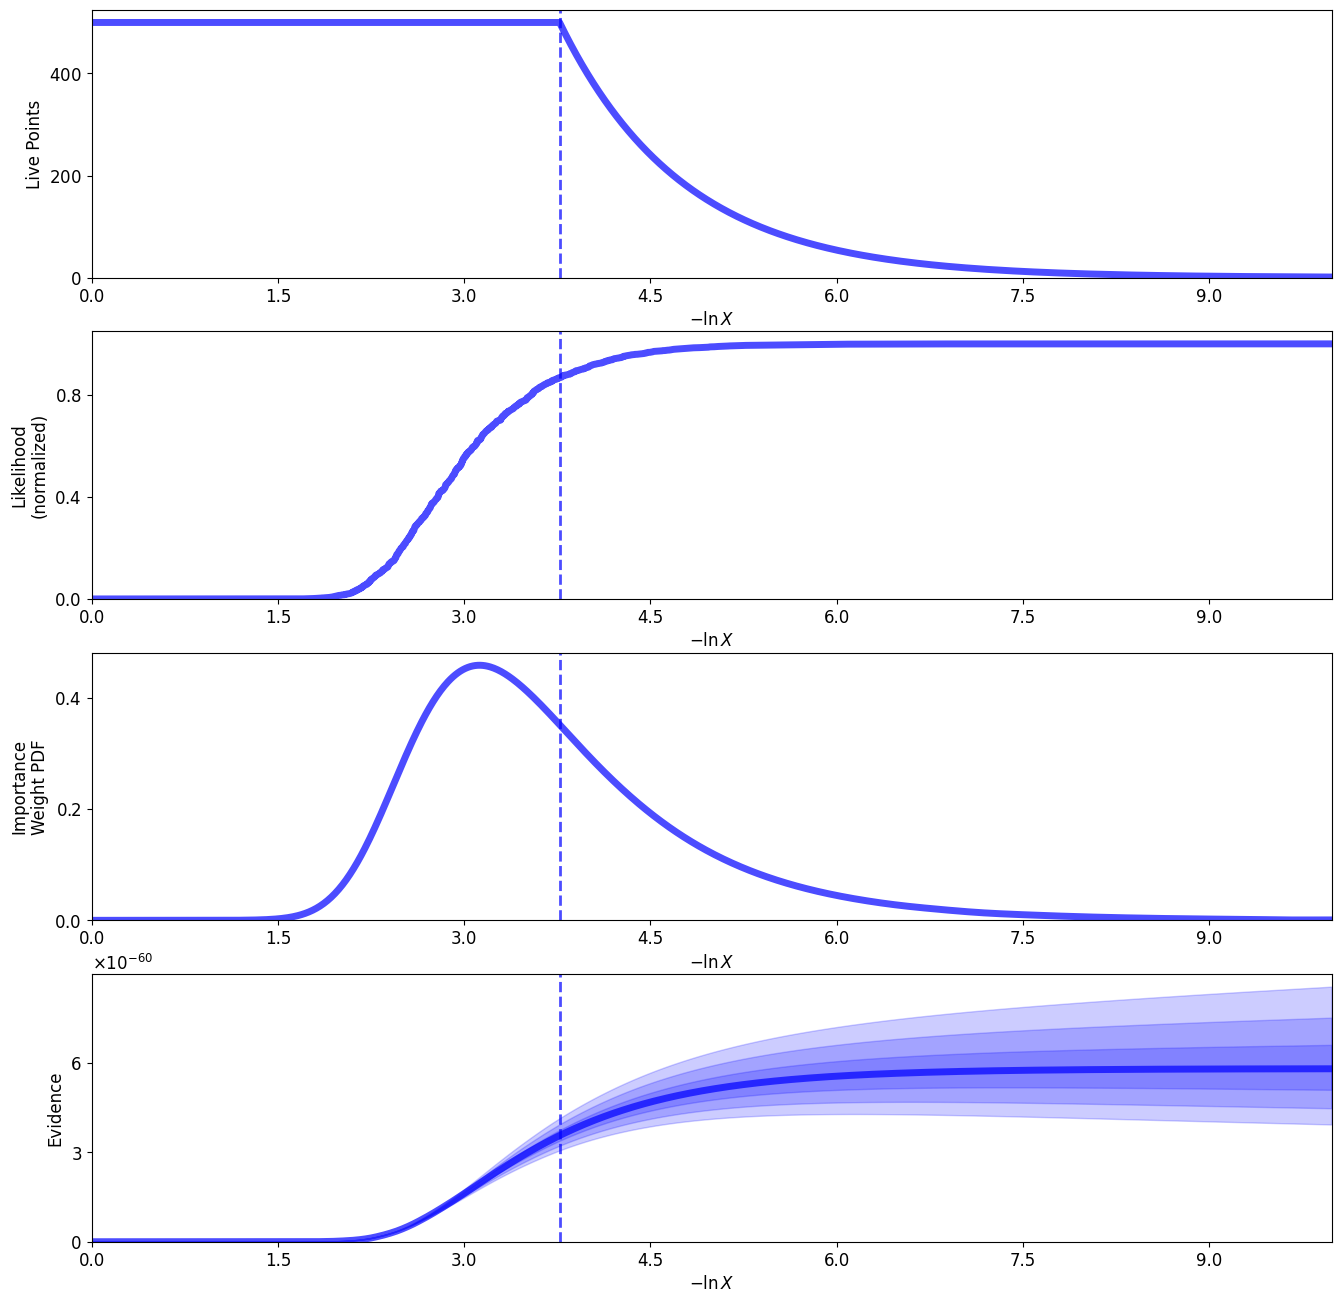

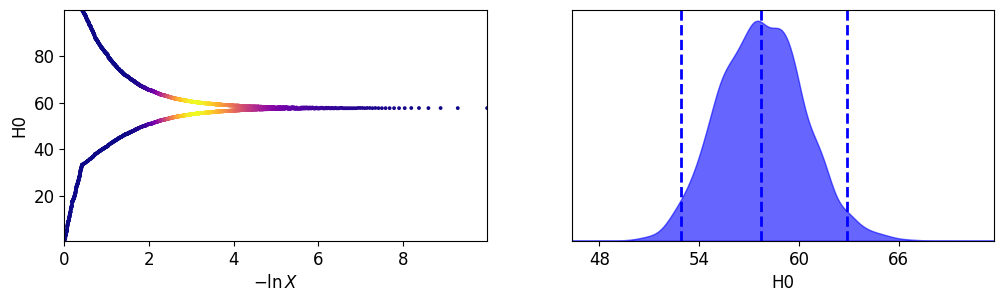

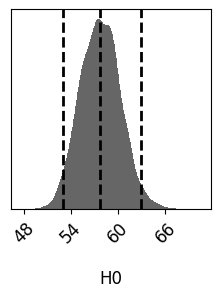

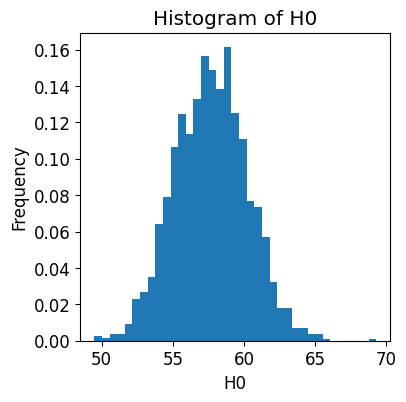

In [20]:
ndim = 1
labels = ["H0"]
def ptform1(theta):
    H0 = theta[0]
    H0 = 100 * H0           # Uniform in [0, 100]
    return np.array([H0])
def logLikelihood1(theta,z,mu,dmu):
    return np.sum(norm(loc = model1(theta,z), scale = dmu).logpdf(mu))
def model1(theta, z):
    cosmo_tmp = LambdaCDM(H0=theta[0], Om0=1, Ode0=0)
    mu_model = cosmo_tmp.distmod(z).value
    return mu_model
sampler2 = dynesty.NestedSampler(logLikelihood1, ptform1, ndim,logl_args=(z_sample,mu_sample,dmu))
sampler2.run_nested()
sresults2 = sampler2.results
Z_No_OmegaL = plot(labels,sresults2)

print('The Bayes factor of OmegaL vs No OmegaL is: ', np.log(Z_OmegaL/Z_No_OmegaL))

With these data, no model is prefered over one other. These data do not put a strong constraint on omegaL